<h1 style="color:#6c63ff; font-weight:bold;">Gym Data Modeling</p>

<h2 style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">Index</h2>


<style>
a { color: #6c63ff !important; }
</style>

<div style="padding: 10px 0; color:#6c63ff;">

**6. Imports**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[6.1 Libraries Imports](#imports)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[6.2 Gym Data Importation](#gym-data)


**7. Clustering**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.1 Elbow ](#elbow)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.2 Silhouette ](#silhouette)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.3 K-Means ](#kmeans)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.4 Hierarchical Clustering ](#hclustering)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.5 Self Organizing Map](#som)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.6 Comparing Algorithms ](#comparing-algorithms)

**8. Cluster Analysis**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[8.1 Cluster Creation ](#clucreation)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[8.2 Cluster Visualization](#cluview)

**9. Conclusions**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[9.1 Summary of Findings ](#fisuma)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[9.2 Business Recommendations](#bureco)


</div>

<h2 id = "imports" style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">6. Imports</h2>

<h3 style="color:#6c63ff; padding-bottom:5px;">Libraries Imports</h3>

In [36]:
!pip install minisom

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from minisom import MiniSom
import matplotlib.pyplot as plt
import seaborn as sns

<h3 style="color:#6c63ff; padding-bottom:5px;">Gym Data Importation</h3>

In [38]:
data = pd.read_csv('cleaned_gym_membership.csv')

In [39]:
num_variables = ["Age", "visit_per_week", "avg_day", "day_sin", "day_cos", "ratio_cardio", "ratio_strength", "ratio_mind_body", "total_minutes", "avg_time_in_gym", "num_classes_attended","Berry Boost", "Lemon", "Passion Fruit", "Coconut Pineapple", "Orange", "Black Currant"]
cat_variables = ['gender', 'abonoment_type', 'name_personal_trainer', 'uses_sauna']

<h2 id = "imports" style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">7. Data Reduction</h2>

As we know that some variables have some kind of relationship, we can try to reduce the dimensionality by using some algorithms like PCA

<h3 id = "imports" style="color:#6c63ff;"> Classes Ratios </h3>

We have <code>ratio_cardio</code>, <code>ratio_streght</code> and <code>ratio_mind_body</code> all refering to the amount of classes that each person has of each type. Therefore it makes sense to test PCA on them.

In [40]:
class_ratios = data[["ratio_cardio", "ratio_strength", "ratio_mind_body"]]
class_ratios.head()

,ratio_cardio,ratio_strength,ratio_mind_body
0,0.333333,0.666667,0.000000
1,0.000000,0.000000,0.000000
2,0.000000,1.000000,0.000000
3,0.000000,0.000000,0.000000
4,0.666667,0.000000,0.333333


In [41]:
class_ratios_scaled = StandardScaler().fit_transform(class_ratios)

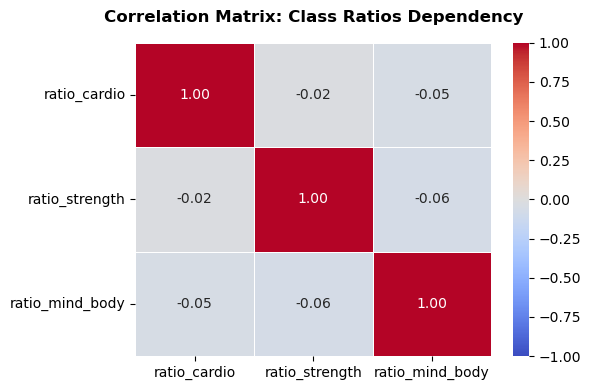

In [42]:
corr_matrix = class_ratios.corr()

plt.figure(figsize=(6, 4))


sns.heatmap(
    corr_matrix,
    annot=True, 
    cmap="coolwarm", 
    vmin=-1,
    vmax=1, 
    fmt=".2f",
    linewidths=0.5,
)


plt.title(
    "Correlation Matrix: Class Ratios Dependency",
    fontsize=12,
    weight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

In [43]:
pca_ratios = PCA(n_components=2)
class_ratios_clustering = pca_ratios.fit_transform(class_ratios_scaled)

class_ratios_clustering = pd.DataFrame(class_ratios_clustering, columns=["Training_Profile_PC1", "Training_Profile_PC2"])

Let's test the PCA comparing the KMeans result using the sillhouete score:

In [51]:
# Experiment A: Clustering with the 3 raw scaled ratio variables
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(class_ratios_scaled)
score_raw = silhouette_score(class_ratios_scaled, labels_raw)

# Experiment B: Clustering with the 2 PCA components
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(class_ratios_clustering)
score_pca = silhouette_score(class_ratios_clustering, labels_pca)

print(f"Silhouette Score using Raw Variables: {score_raw:.4f}")
print(f"Silhouette Score using PCA Components: {score_pca:.4f}")

Silhouette Score using Raw Variables: 0.6344
Silhouette Score using PCA Components: 0.6449


As there is not much difference, we might actually not gain a lot from using PCA on these 3 variables. Still, let's see how much information have we lost:

In [52]:
print(f"Total Variance Retained: {pca_ratios.explained_variance_ratio_.sum() * 100:.2f}%")

Total Variance Retained: 69.71%


We have only retained around 70% of the variance, meaning this PCA is actually making no good to our clustering.